# Lab 02 · CT Projection and Reconstruction
**Lý Chính Tân · HCMUT · Medical Imaging coursework**

Progress from projection/sinograms to unfiltered backprojection, Fourier filtering, then SIRT and CGLS.
Library Radon examples and the educational discrete system use **different projectors** and are labeled
separately. Each reconstruction is compared with its own known input image.

## Saved execution
The outputs shown below were executed on the supplied coursework data on September 12, 2026. The console records `Input mode: local`. The original image files are not redistributed. The configuration defaults to `demo` so a new reader can run this notebook without the coursework data; choose `local` and set `DATA_ROOT` to reproduce the saved coursework figures. Changing input mode replaces the saved outputs when cells are rerun.


## 1. Setup and experiment settings

In [1]:
from pathlib import Path
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Works when Jupyter starts in the repository root or notebooks/.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'imaging_labs').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook inside the medical-imaging-labs repository.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from imaging_labs.common import normalize_display, image_metrics, show_images, save_figure

# Choose 'demo' or 'local'. Local mode never falls back silently to demo data.
MODE = os.environ.get('IMAGING_LABS_MODE', 'demo')
DATA_ROOT = Path(os.environ.get('IMAGING_LABS_DATA', str(ROOT / 'data')))
OUTPUT_ROOT = Path(os.environ.get('IMAGING_LABS_OUTPUT', str(ROOT / 'results'))) / MODE
if MODE not in {'demo', 'local'}:
    raise ValueError("MODE must be 'demo' or 'local'")
plt.rcParams.update({'figure.dpi': 100, 'font.size': 10})
print('Input mode:', MODE)

Input mode: local


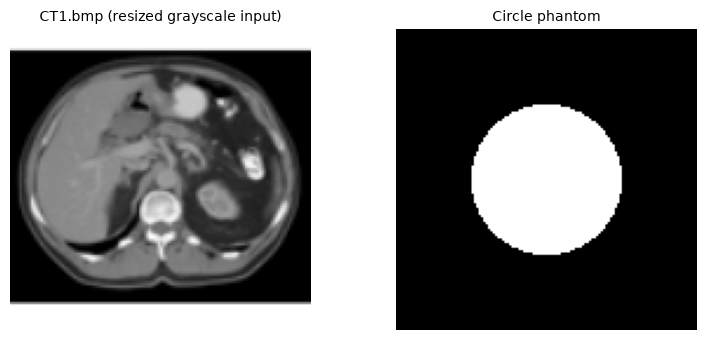

In [2]:
from PIL import Image
from skimage.transform import resize
from imaging_labs.ct import circle_phantom, projection_matrix, fourier_filter, sirt, cgls, radon, iradon

CT_PATH = DATA_ROOT / 'ct' / 'CT1.bmp'
IMAGE_SIZE = 128
ITERATIVE_SIZE = 64
ANGLE_COUNTS = (1, 10, 180, 360)
ITERATIONS = 80
OUTPUT = OUTPUT_ROOT / 'ct'
OUTPUT.mkdir(parents=True, exist_ok=True)
if MODE == 'local':
    if not CT_PATH.is_file():
        raise FileNotFoundError('CT1.bmp is missing from DATA_ROOT/ct.')
    source = np.asarray(Image.open(CT_PATH).convert('L'), dtype=float) / 255
    source = resize(source, (IMAGE_SIZE, IMAGE_SIZE), anti_aliasing=True, preserve_range=True)
    source_name = 'CT1.bmp (resized grayscale input)'
else:
    from skimage.data import shepp_logan_phantom
    source = resize(shepp_logan_phantom(), (IMAGE_SIZE, IMAGE_SIZE), anti_aliasing=True)
    source_name = 'Synthetic Shepp-Logan phantom'
images = {source_name: source, 'Circle phantom': circle_phantom(IMAGE_SIZE)}
fig = show_images(list(images.values()), list(images), columns=2, limits=(0, 1))
plt.show()

## 2. Projection and sinograms at 1, 10, 180 and 360 views
The counts refer to distinct projection directions evenly sampled over **[0°, 180°)** for a parallel-beam
geometry; 360 views does not mean a 360° acquisition. `circle=False` keeps the full square field of view.

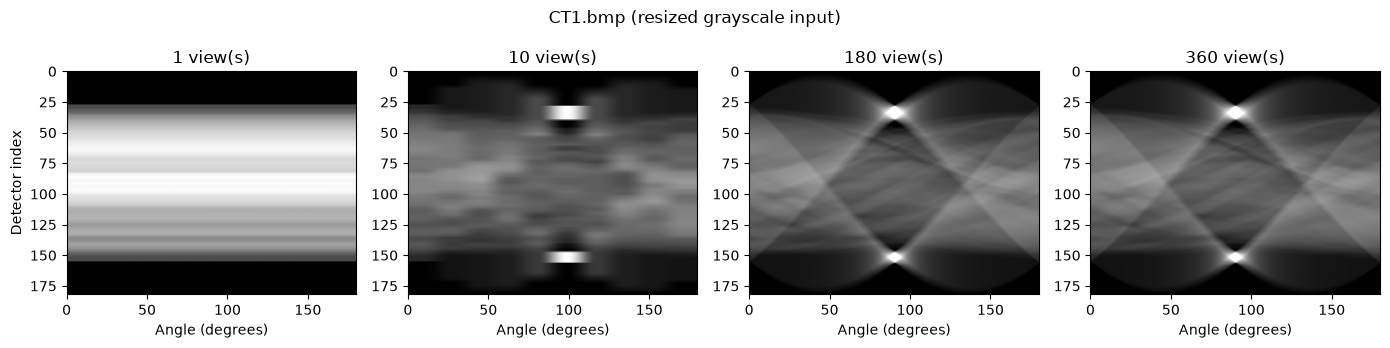

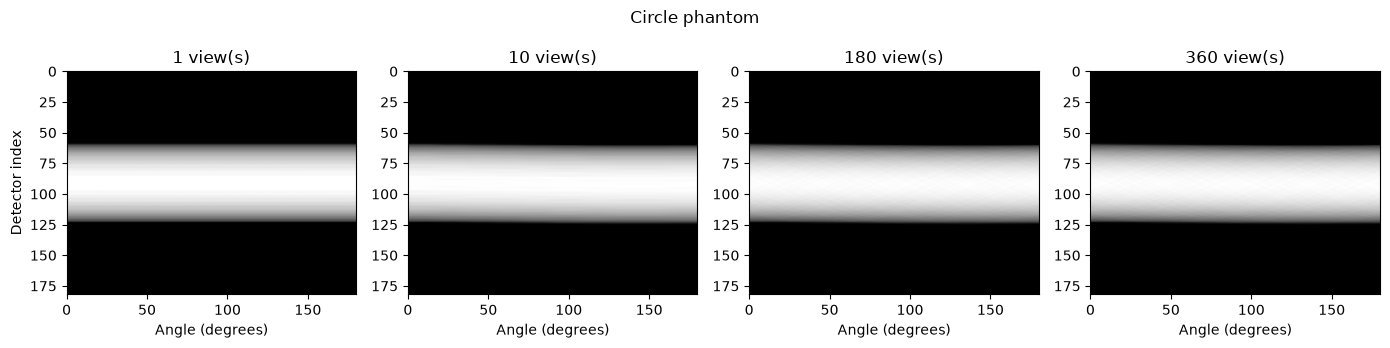

In [3]:
angle_sets = {count: np.linspace(0, 180, count, endpoint=False) for count in ANGLE_COUNTS}
sinograms = {}
for name, image in images.items():
    sinograms[name] = {count: radon(image, theta=angles, circle=False) for count, angles in angle_sets.items()}
    fig, axes = plt.subplots(1, len(ANGLE_COUNTS), figsize=(14, 3.5))
    for ax, (count, sino) in zip(axes, sinograms[name].items()):
        ax.imshow(sino, cmap='gray', aspect='auto', extent=(0, 180, sino.shape[0], 0))
        ax.set(title=f'{count} view(s)', xlabel='Angle (degrees)')
    axes[0].set_ylabel('Detector index')
    fig.suptitle(name)
    fig.tight_layout()
    plt.show()

## 3. Unfiltered backprojection
Backprojection spreads each measured projection over the image. The result is blurred without a
reconstruction filter. These figures use independent display windows, so they compare structure rather
than calibrated intensity.

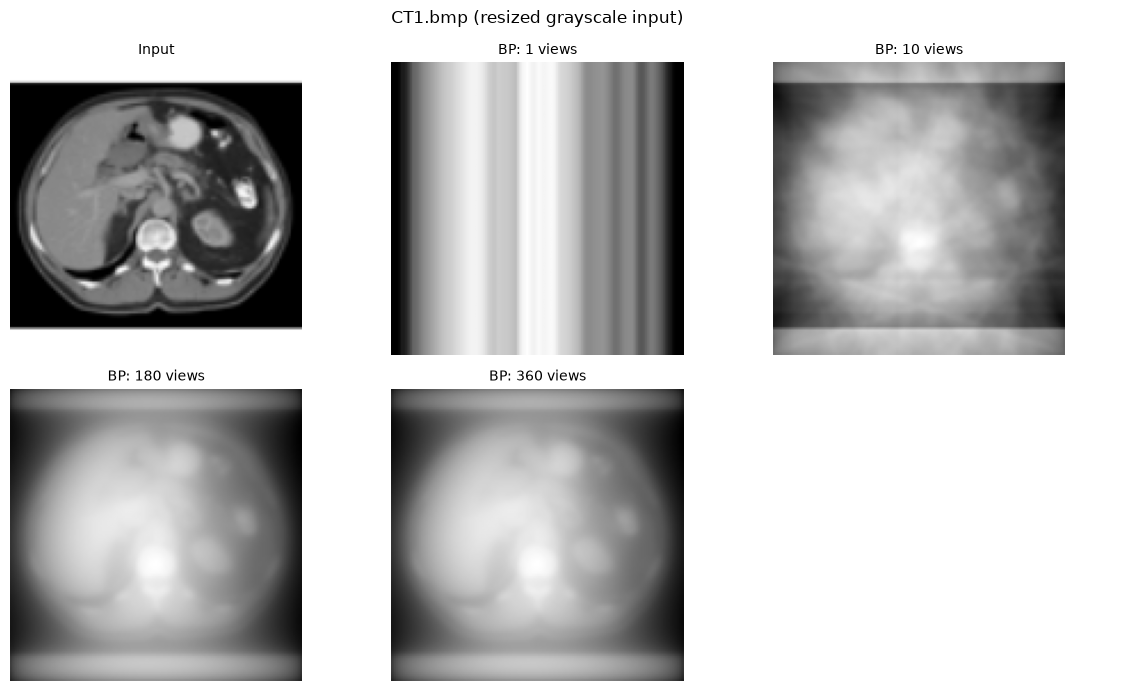

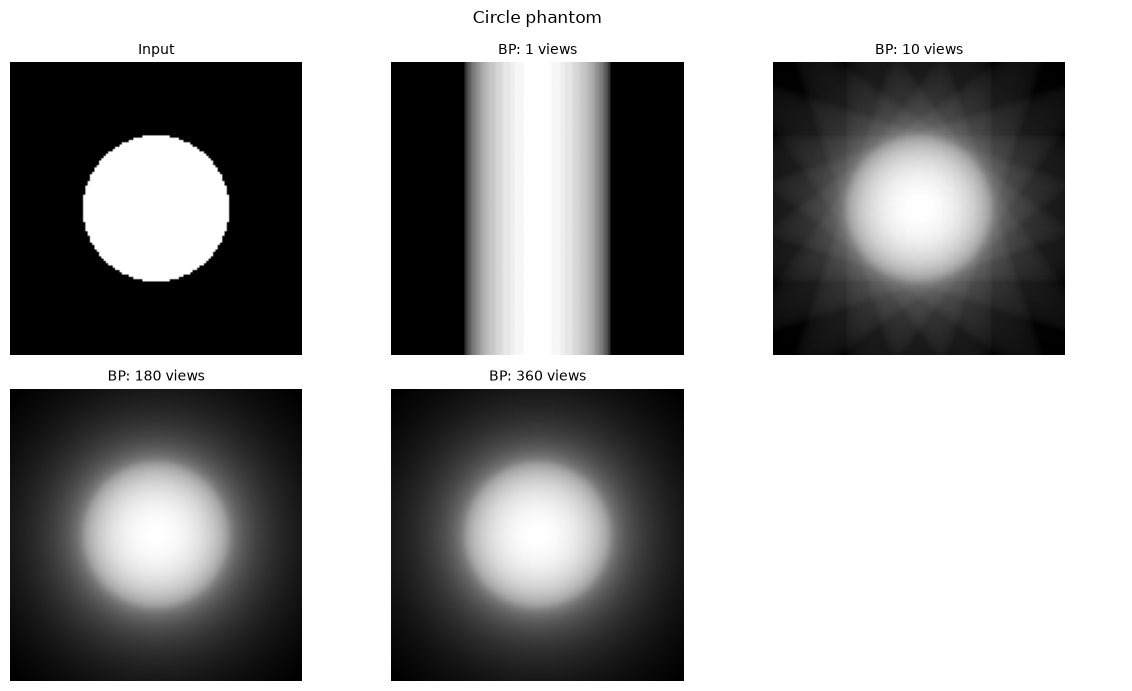

In [4]:
for name, image in images.items():
    reconstructions = [iradon(sinograms[name][count], theta=angle_sets[count],
                             filter_name=None, output_size=IMAGE_SIZE, circle=False) for count in ANGLE_COUNTS]
    fig = show_images([image] + reconstructions, ['Input'] + [f'BP: {count} views' for count in ANGLE_COUNTS])
    fig.suptitle(name)
    fig.tight_layout()
    plt.show()

## 4. FFT → frequency filter → IFFT → backprojection
Show a zero-padded continuous ramp and windowed variants explicitly. Then use scikit-image's built-in
FBP filters as the numerical reference. The manual filter is an educational approximation, not an exact
copy of the library's discrete ramp correction. Quantitative metrics retain the original [0, 1] scale:
reconstructions are **not independently min-max normalized** before scoring.

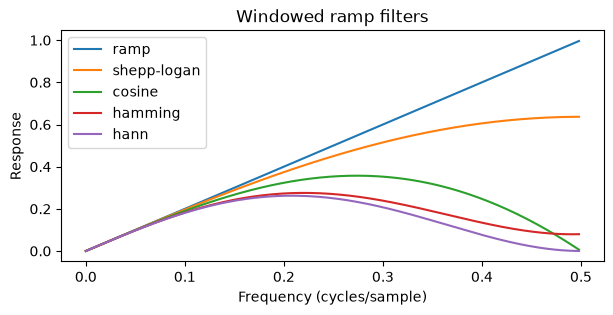

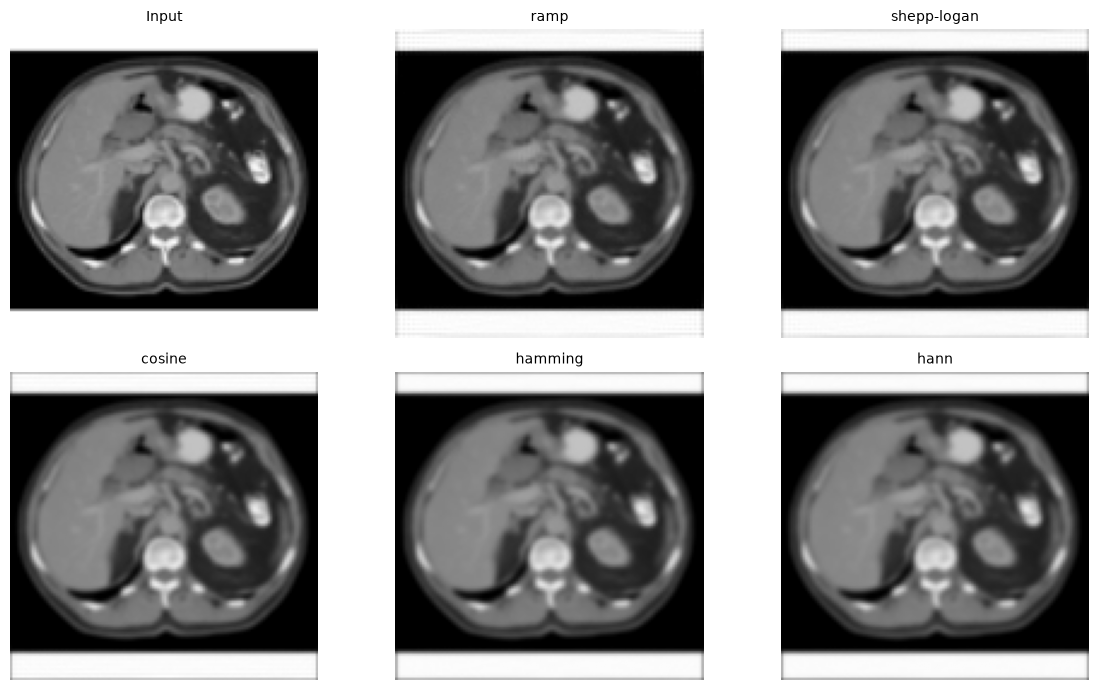

,image,method,mae,rmse,psnr_db,ssim
0,CT1.bmp (resized grayscale input),ramp,0.0129,0.0199,34.0314,0.9631
1,CT1.bmp (resized grayscale input),shepp-logan,0.0153,0.0261,31.6728,0.9569
2,CT1.bmp (resized grayscale input),cosine,0.0212,0.0428,27.3735,0.9375
3,CT1.bmp (resized grayscale input),hamming,0.0260,0.0523,25.6302,0.9178
4,CT1.bmp (resized grayscale input),hann,0.0273,0.0555,25.1145,0.9130
5,Circle phantom,ramp,0.0088,0.0323,29.8031,0.9511
6,Circle phantom,shepp-logan,0.0087,0.0360,28.8715,0.9572
7,Circle phantom,cosine,0.0090,0.0437,27.1852,0.9613
8,Circle phantom,hamming,0.0097,0.0482,26.3454,0.9577
9,Circle phantom,hann,0.0099,0.0497,26.0745,0.9568


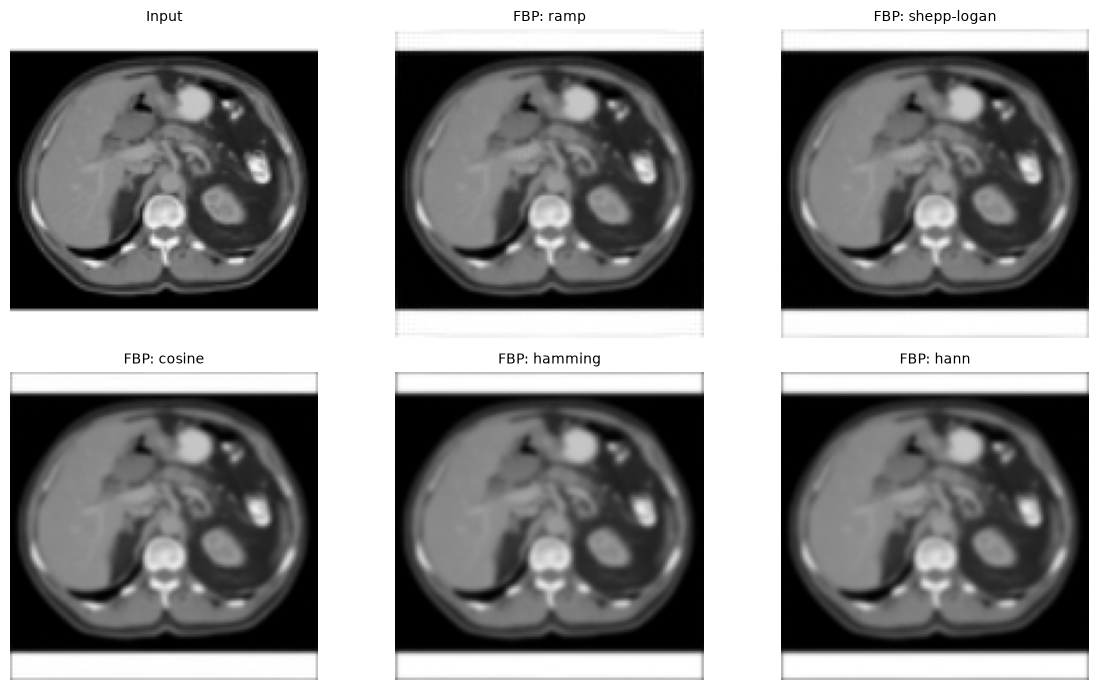

In [5]:
FILTERS = ('ramp', 'shepp-logan', 'cosine', 'hamming', 'hann')
theta = angle_sets[180]
sino = sinograms[source_name][180]
fig, ax = plt.subplots(figsize=(7, 3))
manual_reconstructions = {}
for name in FILTERS:
    filtered, frequency, response = fourier_filter(sino, name)
    positive = frequency >= 0
    ax.plot(frequency[positive], response[positive], label=name)
    manual_reconstructions[name] = iradon(filtered, theta=theta, filter_name=None,
                                         output_size=IMAGE_SIZE, circle=False)
ax.set(xlabel='Frequency (cycles/sample)', ylabel='Response', title='Windowed ramp filters')
ax.legend()
plt.show()
fig = show_images([source] + list(manual_reconstructions.values()), ['Input'] + list(FILTERS), limits=(0, 1))
save_figure(fig, OUTPUT, 'manual_fourier_filters.png')
plt.show()

fbp_rows = []
fbp = {}
for image_name, image in images.items():
    image_sino = sinograms[image_name][180]
    for filter_name in FILTERS:
        reconstruction = iradon(image_sino, theta=theta, filter_name=filter_name,
                               output_size=IMAGE_SIZE, circle=False)
        fbp_rows.append({'image': image_name, 'method': filter_name, **image_metrics(image, reconstruction)})
        if image_name == source_name:
            fbp[filter_name] = reconstruction
fbp_metrics = pd.DataFrame(fbp_rows)
display(fbp_metrics.round(4))
fbp_metrics.to_csv(OUTPUT / 'fbp_metrics.csv', index=False)
fig = show_images([source] + list(fbp.values()), ['Input'] + [f'FBP: {name}' for name in FILTERS], limits=(0, 1))
save_figure(fig, OUTPUT, 'fbp_comparison.png')
plt.show()

## 5. A matched discrete forward/transpose pair
The original manual projector assigned image pixels to detector bins. Here linear interpolation deposits
each pixel into two neighboring bins, represented by a sparse matrix `A`. Its exact transpose `A.T`
is used for iterative reconstruction. This avoids treating `iradon` as the exact adjoint of `radon`.
The inner-product check below verifies the forward/transpose relationship on independent vectors.

In [6]:
iterative_angles = np.linspace(0, 180, 180, endpoint=False)
A, detectors = projection_matrix(ITERATIVE_SIZE, iterative_angles)
rng = np.random.default_rng(23)
x_check, y_check = rng.normal(size=A.shape[1]), rng.normal(size=A.shape[0])
adjoint_error = abs(np.dot(A @ x_check, y_check) - np.dot(x_check, A.T @ y_check))
print('System matrix:', A.shape, '| nonzero entries:', A.nnz)
print('Absolute adjoint identity error:', adjoint_error)

System matrix: (16740, 4096) | nonzero entries: 1474560
Absolute adjoint identity error: 9.094947017729282e-13


## 6. SIRT and CGLS
SIRT applies row/column normalization and a non-negativity constraint. CGLS minimizes a linear
least-squares objective with the matched transpose; it is not clipped during or after optimization.
Residual histories include iteration zero and are measured **after** every update. Both methods use
the same measurements within this experiment, separately from the library FBP experiment.

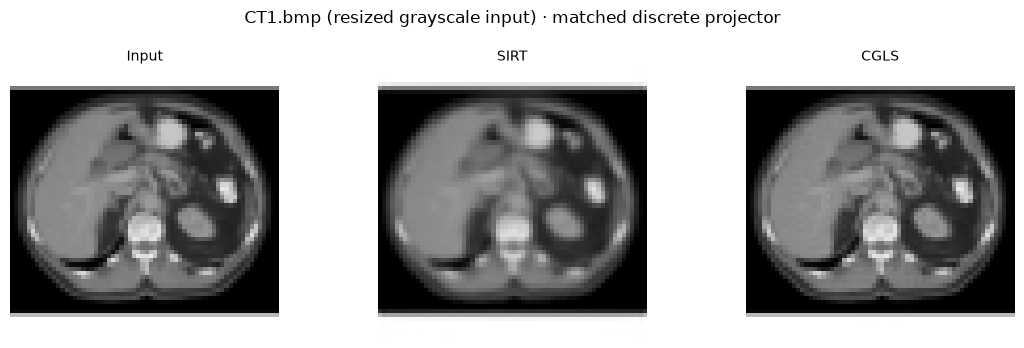

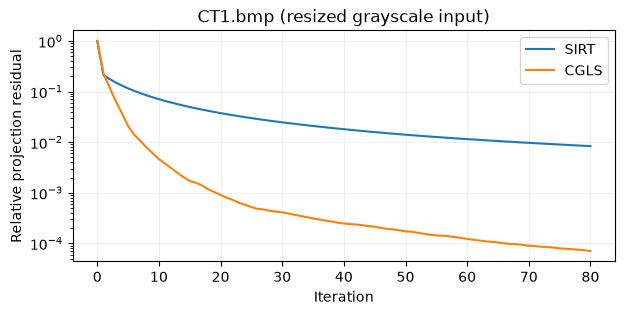

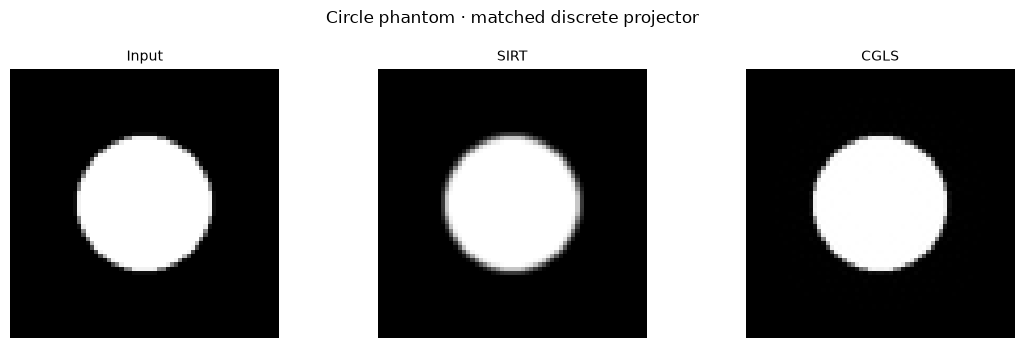

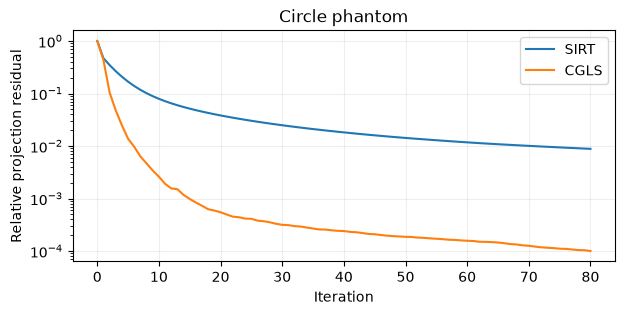

,image,method,relative_residual,mae,rmse,psnr_db,ssim
0,CT1.bmp (resized grayscale input),SIRT,0.00835,0.02077,0.03494,29.13285,0.96875
1,CT1.bmp (resized grayscale input),CGLS,0.00007,0.00352,0.00556,45.10032,0.99770
2,Circle phantom,SIRT,0.00884,0.00668,0.02807,31.03444,0.97290
3,Circle phantom,CGLS,0.00010,0.00273,0.00465,46.64987,0.99217


In [7]:
iterative_rows = []
for name, original in images.items():
    reference = resize(original, (ITERATIVE_SIZE, ITERATIVE_SIZE), anti_aliasing=True, preserve_range=True)
    measurements = A @ reference.ravel()
    reconstructions, histories = {}, {}
    for method, solver in [('SIRT', sirt), ('CGLS', cgls)]:
        vector, history = solver(A, measurements, iterations=ITERATIONS)
        reconstruction = vector.reshape(reference.shape)
        reconstructions[method], histories[method] = reconstruction, history
        iterative_rows.append({'image': name, 'method': method,
                               'relative_residual': float(history[-1]), **image_metrics(reference, reconstruction)})
    fig = show_images([reference] + list(reconstructions.values()), ['Input'] + list(reconstructions), limits=(0, 1))
    fig.suptitle(name + ' · matched discrete projector')
    fig.tight_layout()
    save_figure(fig, OUTPUT, 'iterative_' + ('source' if name == source_name else 'circle') + '.png')
    plt.show()
    fig, ax = plt.subplots(figsize=(7, 3))
    for method, history in histories.items():
        ax.semilogy(np.arange(len(history)), np.maximum(history, 1e-16), label=method)
    ax.set(xlabel='Iteration', ylabel='Relative projection residual', title=name)
    ax.legend()
    ax.grid(alpha=.2)
    plt.show()
iterative_metrics = pd.DataFrame(iterative_rows)
display(iterative_metrics.round(5))
iterative_metrics.to_csv(OUTPUT / 'iterative_metrics.csv', index=False)

## 7. Discussion
- Few projection directions leave substantial missing angular information.
- FBP filter windows trade edge sharpness for suppression of high-frequency components.
- Iterative results depend on the forward model, sampling and stopping criterion.
- A BMP input is an image used to simulate projections; these are not measured scanner projections or calibrated Hounsfield units.
- Display normalization is separate from quantitative scoring, so amplitude errors remain visible in RMSE/PSNR/SSIM.

**References:** supplied Lab 2 CT handout, Le Nhat Tan, HCMUT;
[scikit-image Radon tutorial](https://scikit-image.org/docs/stable/auto_examples/transform/plot_radon_transform.html);
[transform API](https://scikit-image.org/docs/stable/api/skimage.transform.html).